In [21]:
import pandas as pd
import numpy as np


df = pd.read_csv("/kaggle/input/datasets/hngkininh/final-comment-data/final_segment_data.csv")
# Giả sử df là dataframe chứa 'comment' và 'label_id'
# 1. Thống kê độ dài comment (tính bằng số từ)
doc_lengths = [len(str(text).split()) for text in df['comment']]
max_seq_len = int(np.percentile(doc_lengths, 95)) # Chọn độ dài bao phủ 95% dữ liệu
print(f"Độ dài tối ưu (95th percentile): {max_seq_len}")

# 2. Thống kê số lượng từ duy nhất
from tensorflow.keras.preprocessing.text import Tokenizer
tokenizer = Tokenizer()
tokenizer.fit_on_texts(df['comment'])
total_words = len(tokenizer.word_index)
print(f"Tổng số từ vựng duy nhất: {total_words}")

# Thiết lập thông số dựa trên kết quả trên
MAX_VOCAB_SIZE = min(10000, total_words) # Thường giới hạn 10k để tránh nhiễu
MAX_SEQUENCE_LENGTH = max_seq_len
EMBEDDING_DIM = 64 # Số chiều vector mặc định cho Word Embedding

Độ dài tối ưu (95th percentile): 43
Tổng số từ vựng duy nhất: 6150


In [22]:
from sklearn.model_selection import train_test_split

# Chia Train và tập còn lại (Temp)
X_train_raw, X_temp, y_train, y_temp = train_test_split(
    df['comment'], df['label_id'], test_size=0.3, random_state=42, stratify=df['label_id']
)

# Chia tập Temp thành Validate và Test
X_val_raw, X_test_raw, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"Train: {len(X_train_raw)} | Val: {len(X_val_raw)} | Test: {len(X_test_raw)}")

Train: 6408 | Val: 1373 | Test: 1374


In [23]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Khởi tạo lại tokenizer với giới hạn từ vựng
tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train_raw)

# Chuyển text thành chuỗi số và Padding
def preprocess_text(texts):
    sequences = tokenizer.texts_to_sequences(texts)
    return pad_sequences(sequences, maxlen=MAX_SEQUENCE_LENGTH, padding='post', truncating='post')

X_train = preprocess_text(X_train_raw)
X_val = preprocess_text(X_val_raw)
X_test = preprocess_text(X_test_raw)

In [24]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras import regularizers
from tensorflow.keras.optimizers import Adam

model = Sequential([
    Embedding(MAX_VOCAB_SIZE, EMBEDDING_DIM, input_length=MAX_SEQUENCE_LENGTH),
    
    Bidirectional(LSTM(32, dropout=0.2, recurrent_dropout=0.2, return_sequences=False)),
    
    BatchNormalization(),
    
    # Giảm L2 xuống để tránh bóp nghẹt mô hình
    Dense(32, activation='relu', kernel_regularizer=regularizers.l2(0.01)),
    
    # Dropout vừa phải
    Dropout(0.5), 
    
    Dense(3, activation='softmax')
])

# Thử giảm learning rate thấp hơn một chút nếu val_loss dao động mạnh
opt = Adam(learning_rate=0.0001)

model.compile(optimizer=opt, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/12
201/201 ━━━━━━━━━━━━━━━━━━━━ 42s 179ms/step - accuracy: 0.4467 - loss: 1.5510 - val_accuracy: 0.3613 - val_loss: 1.4756
Epoch 2/12
201/201 ━━━━━━━━━━━━━━━━━━━━ 35s 176ms/step - accuracy: 0.5809 - loss: 1.3028 - val_accuracy: 0.7320 - val_loss: 1.3524
Epoch 3/12
201/201 ━━━━━━━━━━━━━━━━━━━━ 35s 176ms/step - accuracy: 0.6951 - loss: 1.1202 - val_accuracy: 0.8077 - val_loss: 1.0754
Epoch 4/12
201/201 ━━━━━━━━━━━━━━━━━━━━ 36s 177ms/step - accuracy: 0.7796 - loss: 0.9192 - val_accuracy: 0.8339 - val_loss: 0.8525
Epoch 5/12
201/201 ━━━━━━━━━━━━━━━━━━━━ 35s 175ms/step - accuracy: 0.8204 - loss: 0.7981 - val_accuracy: 0.8507 - val_loss: 0.7440
Epoch 6/12
201/201 ━━━━━━━━━━━━━━━━━━━━ 35s 175ms/step - accuracy: 0.8495 - loss: 0.7156 - val_accuracy: 0.8660 - val_loss: 0.6794
Epoch 7/12
201/201 ━━━━━━━━━━━━━━━━━━━━ 35s 175ms/step - accuracy: 0.8739 - loss: 0.6285 - val_accuracy: 0.8776 - val_loss: 0.6232
Epoch 8/12
201/201 ━━━━━━━━━━━━━━━━━━━━ 35s 174ms/step - accuracy: 0.8909 - loss: 0

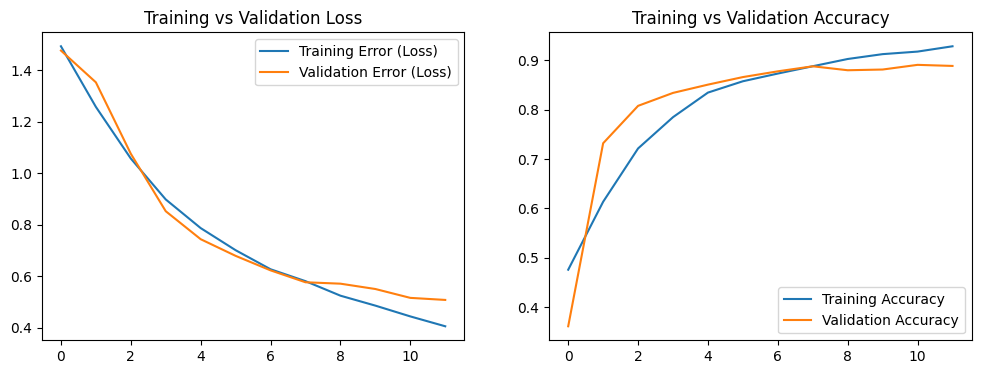

In [25]:
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
from sklearn.utils import class_weight

# Tự động dừng nếu val_loss không giảm sau 3 epoch
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Tính toán trọng số dựa trên nhãn thật (y_train)
weights = class_weight.compute_class_weight('balanced', 
                                            classes=np.unique(y_train), 
                                            y=y_train)
class_weights_dict = dict(enumerate(weights))

# Trong hàm fit, thêm tham số class_weight
history = model.fit(
    X_train, y_train,
    epochs=12, # Có thể tăng nhẹ vì đã có early_stop
    batch_size=32,
    validation_data=(X_val, y_val),
    class_weight=class_weights_dict, # Ép mô hình học kỹ lớp ít mẫu
    callbacks=[early_stop]
)



# VẼ BIỂU ĐỒ LỖI (ERROR/LOSS)
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Error (Loss)')
plt.plot(history.history['val_loss'], label='Validation Error (Loss)')
plt.title('Training vs Validation Loss')
plt.legend()

# VẼ BIỂU ĐỒ ĐỘ CHÍNH XÁC (ACCURACY)
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.show()

In [28]:
from sklearn.metrics import classification_report

y_pred = np.argmax(model.predict(X_test), axis=1)
print(classification_report(y_test, y_pred, target_names=['CLEAN', 'OFFENSIVE', 'HATE']))

43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step
              precision    recall  f1-score   support

       CLEAN       0.94      0.90      0.92       844
   OFFENSIVE       0.83      0.90      0.87       253
        HATE       0.80      0.86      0.83       277

    accuracy                           0.89      1374
   macro avg       0.86      0.88      0.87      1374
weighted avg       0.89      0.89      0.89      1374



43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step


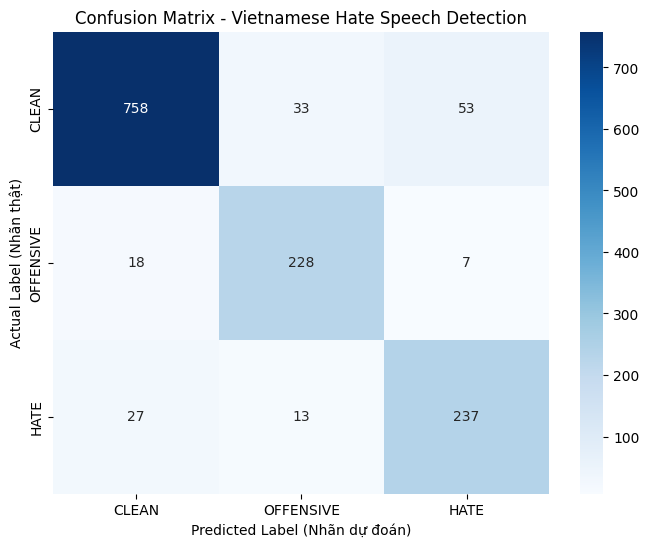

In [29]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# 1. Dự đoán nhãn trên tập test
y_pred_probs = model.predict(X_test) 
y_pred = np.argmax(y_pred_probs, axis=1) # Chuyển từ xác suất sang nhãn (0, 1, 2)

# 2. Tạo ma trận nhầm lẫn
# Thay đổi tên các nhãn tương ứng với bài toán của bạn
label_names = ['CLEAN', 'OFFENSIVE', 'HATE'] 
cm = confusion_matrix(y_test, y_pred)

# 3. Vẽ biểu đồ
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=label_names, 
            yticklabels=label_names)

plt.title('Confusion Matrix - Vietnamese Hate Speech Detection')
plt.ylabel('Actual Label (Nhãn thật)')
plt.xlabel('Predicted Label (Nhãn dự đoán)')
plt.show()